# 01 — Data Cleaning

Pipeline:
1. Load raw `results_linux.csv`
2. Detect & remove outliers (**boxplot / 1.5×IQR fence**, per language × benchmark group, on CPU energy + execution time)
3. Convert units to human-readable values
4. Export `results_clean_runs.csv`

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RAW_CSV  = Path('../results/results_linux.csv')
RUNS_CSV = Path('../results/results_clean_runs.csv')
FIGS_DIR = Path('../results/figs')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load raw data

In [46]:
df = pd.read_csv(RAW_CSV)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1440, 16)


,run_id,measured_at,language,benchmark,cpu_carbon_rapl_msr_component-package_0-ug,cpu_energy_rapl_msr_component-package_0-uj,disk_total_read_cgroup_container-container-bytes,disk_total_write_cgroup_container-container-bytes,embodied_carbon_share_machine-system-ug,memory_carbon_rapl_msr_component-dram_0-ug,memory_energy_rapl_msr_component-dram_0-uj,network_carbon_formula_global-formula-ug,network_energy_formula_global-formula-uj,network_power_formula_global-formula-mw,network_total_cgroup_container-container-bytes,phase_time_syscall_system-system-us
0,a2c3962c-9c86-4761-ab7d-4651aabc5d14,2026-05-28 18:51:57,c,mandelbrot,3658,39430655,221184,0,2000,58,626459,0,0,0,0,1394177
1,5fac6597-61b8-4acf-9496-9c17bc86348d,2026-05-28 18:49:08,c,fasta,3580,38591180,0,0,2049,80,861689,0,0,0,0,1427691
2,7c9855c9-6d36-4c0a-a86a-0f3b1c00aa42,2026-05-28 18:46:08,c,spectral-norm,1054,11359251,221184,0,710,18,194944,0,0,0,0,494856


## 2. Outlier detection & removal (Boxplot / 1.5×IQR fence)

Outliers are identified using the standard boxplot rule: any run whose value falls **outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR]** is flagged.  
Detection is applied **per (language × benchmark) group** on the two primary metrics — CPU energy and execution time — to avoid over-flagging from noisy ancillary columns (disk, network, etc.).

In [47]:
# Numeric metric columns only (exclude identifiers)
ID_COLS     = ['run_id', 'measured_at', 'language', 'benchmark']
METRIC_COLS = [c for c in df.columns if c not in ID_COLS]

# Detect outliers only on the two primary benchmarking signals
KEY_METRICS = [c for c in METRIC_COLS if 'cpu_energy' in c or 'phase_time' in c]
print('Outlier detection on:', KEY_METRICS)

def boxplot_outlier_mask(group: pd.DataFrame, cols: list[str]) -> pd.Series:
    """
    Standard boxplot fence: flag rows outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    on any of the given columns.
    """
    outlier = pd.Series(False, index=group.index)
    for col in cols:
        q1, q3 = group[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:          # constant column in this group — skip
            continue
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier |= (group[col] < lo) | (group[col] > hi)
    return outlier

outlier_flags = (
    df.groupby(['language', 'benchmark'], group_keys=False)
      .apply(lambda g: boxplot_outlier_mask(g, KEY_METRICS))
)

n_outliers = outlier_flags.sum()
print(f'Outlier runs flagged : {n_outliers} / {len(df)}  ({n_outliers/len(df)*100:.1f}%)')

df_clean = df[~outlier_flags].copy()
print(f'Rows after removal   : {len(df_clean)}')

Outlier detection on: ['cpu_energy_rapl_msr_component-package_0-uj', 'phase_time_syscall_system-system-us']
Outlier runs flagged : 160 / 1440  (11.1%)
Rows after removal   : 1280


/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_14048/2875229071.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df[~outlier_flags].copy()


/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_14048/4078096293.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_14048/4078096293.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_14048/4078096293.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_14048/4078096293.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

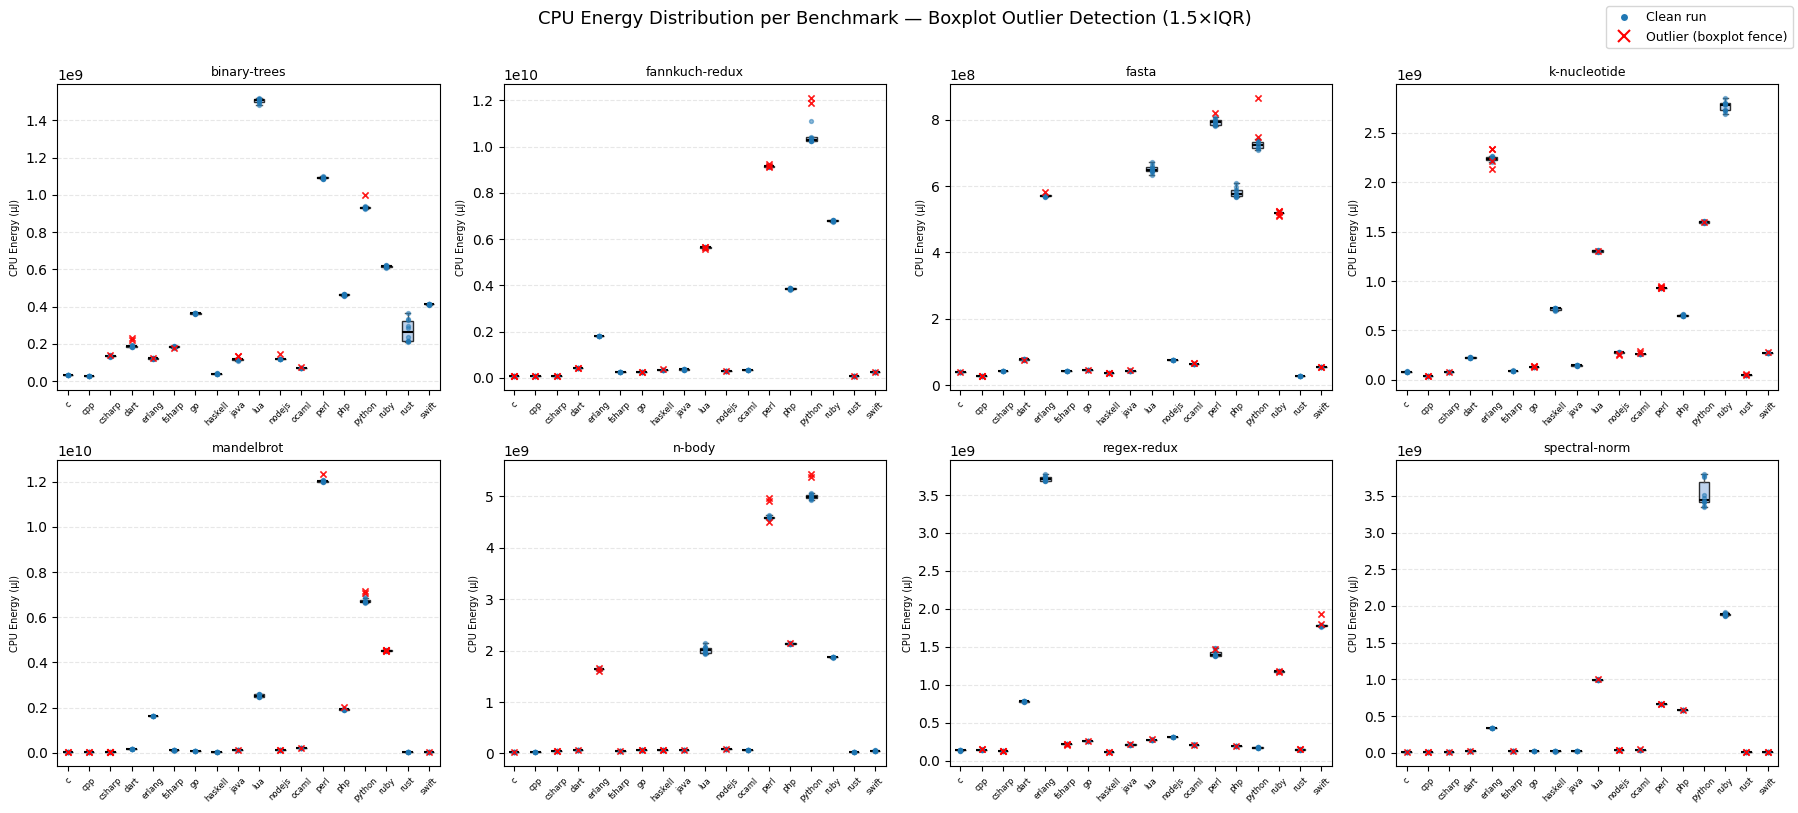

In [48]:
# Visualise outliers — CPU energy boxplots per benchmark, outlier points in red
COL_E      = [c for c in METRIC_COLS if 'cpu_energy' in c][0]
benchmarks = sorted(df['benchmark'].unique())
ncols = 4
nrows = int(np.ceil(len(benchmarks) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, bm in enumerate(benchmarks):
    ax = axes[i]
    sub   = df[df['benchmark'] == bm].copy()
    sub['_outlier'] = outlier_flags.reindex(sub.index, fill_value=False)
    langs = sorted(sub['language'].unique())

    data_clean   = [sub[(sub['language'] == l) & ~sub['_outlier']][COL_E].values for l in langs]
    data_outlier = [sub[(sub['language'] == l) &  sub['_outlier']][COL_E].values for l in langs]

    bp = ax.boxplot(
        data_clean, labels=langs, patch_artist=True, showfliers=False,
        medianprops=dict(color='black', linewidth=1.5),
        boxprops=dict(facecolor='#aec7e8', alpha=0.8),
        whiskerprops=dict(color='#555555'),
        capprops=dict(color='#555555'),
    )

    # Overlay clean runs as small blue dots, outliers as red crosses
    for j, lang in enumerate(langs):
        x = j + 1
        clean_vals   = data_clean[j]
        outlier_vals = data_outlier[j]
        ax.scatter([x] * len(clean_vals),   clean_vals,   color='#1f77b4', s=8,  alpha=0.5, zorder=3)
        ax.scatter([x] * len(outlier_vals), outlier_vals, color='red',     s=20, alpha=0.9, marker='x', zorder=4, linewidths=1.2)

    ax.set_title(bm, fontsize=9)
    ax.set_ylabel('CPU Energy (µJ)', fontsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=6, label='Clean run'),
    Line2D([0], [0], marker='x', color='red', markersize=8, markeredgewidth=1.5, label='Outlier (boxplot fence)', linestyle='None'),
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9, frameon=True)

fig.suptitle('CPU Energy Distribution per Benchmark — Boxplot Outlier Detection (1.5×IQR)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'boxplot_outliers_cpu_energy.pdf', bbox_inches='tight')
plt.show()

In [49]:
# Per-group count after cleaning — flag any group with fewer than 5 clean runs
counts = df_clean.groupby(['language', 'benchmark']).size().rename('n_runs')
low = counts[counts < 5]
if len(low):
    print('⚠ Groups with < 5 clean runs:')
    print(low.to_string())
else:
    print('All groups have ≥ 5 clean runs.')
counts.unstack('benchmark').fillna(0).astype(int)

All groups have ≥ 5 clean runs.


benchmark,binary-trees,fannkuch-redux,fasta,k-nucleotide,mandelbrot,n-body,regex-redux,spectral-norm
language,,,,,,,,
c,10,7,9,10,8,9,10,9
cpp,10,8,7,8,8,10,8,8
csharp,9,8,10,9,5,8,7,9
dart,8,8,9,10,10,9,10,9
erlang,9,10,9,6,10,8,10,10
fsharp,9,10,10,10,10,9,7,9
go,10,8,9,7,10,8,9,10
haskell,10,9,7,10,10,8,8,10
java,8,10,9,10,9,9,9,10


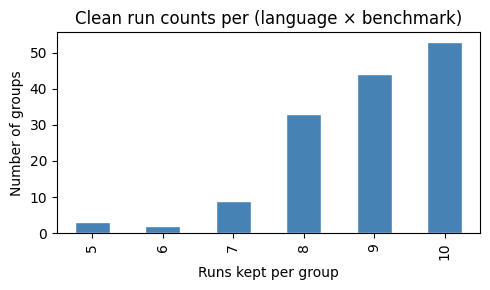

In [50]:
# Visual: distribution of clean run counts per group
fig, ax = plt.subplots(figsize=(5, 3))
counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Runs kept per group')
ax.set_ylabel('Number of groups')
ax.set_title('Clean run counts per (language × benchmark)')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'outlier_counts.pdf', bbox_inches='tight')
plt.show()

## 3. Unit conversions

In [51]:
# Conversion rules keyed by column-name suffix.
# Each entry: (divisor, new_unit_label)
CONVERSIONS = {
    '-ug' : (1e6,    'g'),        # micro-grams  → grams
    '-uj' : (1e6,    'J'),        # micro-Joules → Joules
    '-mw' : (1e3,    'W'),        # milli-Watts  → Watts
    '-us' : (1e3,    'ms'),       # micro-seconds → milli-seconds
    '-bytes': (1e6,  'MB'),       # bytes → MB  (disk/net totals)
}

rename_map = {}
for col in METRIC_COLS:
    for suffix, (divisor, unit) in CONVERSIONS.items():
        if col.endswith(suffix):
            base = col[: -len(suffix)]
            new_col = f'{base}-{unit.lower()}'
            df_clean[new_col] = df_clean[col] / divisor
            rename_map[col] = new_col
            break

# Drop the original raw-unit columns
df_clean = df_clean.drop(columns=list(rename_map.keys()))

METRIC_COLS_CONV = [c for c in df_clean.columns if c not in ID_COLS]
print('Converted columns:')
for old, new in rename_map.items():
    print(f'  {old}  →  {new}')

Converted columns:
  cpu_carbon_rapl_msr_component-package_0-ug  →  cpu_carbon_rapl_msr_component-package_0-g
  cpu_energy_rapl_msr_component-package_0-uj  →  cpu_energy_rapl_msr_component-package_0-j
  disk_total_read_cgroup_container-container-bytes  →  disk_total_read_cgroup_container-container-mb
  disk_total_write_cgroup_container-container-bytes  →  disk_total_write_cgroup_container-container-mb
  embodied_carbon_share_machine-system-ug  →  embodied_carbon_share_machine-system-g
  memory_carbon_rapl_msr_component-dram_0-ug  →  memory_carbon_rapl_msr_component-dram_0-g
  memory_energy_rapl_msr_component-dram_0-uj  →  memory_energy_rapl_msr_component-dram_0-j
  network_carbon_formula_global-formula-ug  →  network_carbon_formula_global-formula-g
  network_energy_formula_global-formula-uj  →  network_energy_formula_global-formula-j
  network_power_formula_global-formula-mw  →  network_power_formula_global-formula-w
  network_total_cgroup_container-container-bytes  →  network_total_cg

## 4. Export

In [52]:
df_clean.to_csv(RUNS_CSV, index=False)
print(f'Saved → {RUNS_CSV}')

Saved → ../results/results_clean_runs.csv
